<a href="https://colab.research.google.com/github/Adidtiasmara/PCVK26_16_Firman/blob/main/week3_16.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**SEL IDENTITAS**
---


In [1]:
# ===== SEL IDENTITAS - JANGAN DIHAPUS, HARUS SEL PERTAMA =====
import sys, platform, hashlib, datetime, zoneinfo
import matplotlib.pyplot as plt
NAMA = 'Muhammad Firman Aditiasmara'
NIM = '244107020094'

N = int(NIM[-3:])
PARAM = {
'b' : (N % 61) + 20,
'a' : round(1.0 + (N % 9) / 10, 1),
'c' : (N % 20) + 30,
'gamma': round(0.4 + (N % 6) * 0.25, 2),
'bit' : (N % 6) + 2,
}
waktu = datetime.datetime.now(zoneinfo.ZoneInfo('Asia/Jakarta'))

print('NAMA :', NAMA)
print('NIM :', NIM, '| N =', N)
for k, v in PARAM.items():
  print('%-6s :' % k, v)
print('WAKTU :', waktu.strftime('%Y-%m-%d %H:%M:%S %Z'))
print('SISTEM :', sys.version.split()[0], platform.platform())
kunci = NIM + '|' + waktu.strftime('%Y-%m-%d')
print('TOKEN :', hashlib.sha256(kunci.encode()).hexdigest()[:16])


NAMA : Muhammad Firman Aditiasmara
NIM : 244107020094 | N = 94
b      : 53
a      : 1.4
c      : 44
gamma  : 1.4
bit    : 6
WAKTU : 2026-09-13 13:59:43 WIB
SISTEM : 3.13.15 Linux-6.6.122+-x86_64-with-glibc2.39
TOKEN : 30da3ee3d2bcee30


In [3]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


---
##**Transformasi Linier Brigtness**
---


Mengubah tingkat kecerahan citra
--------------------------------
Masukkan nilai kecerahan: 40


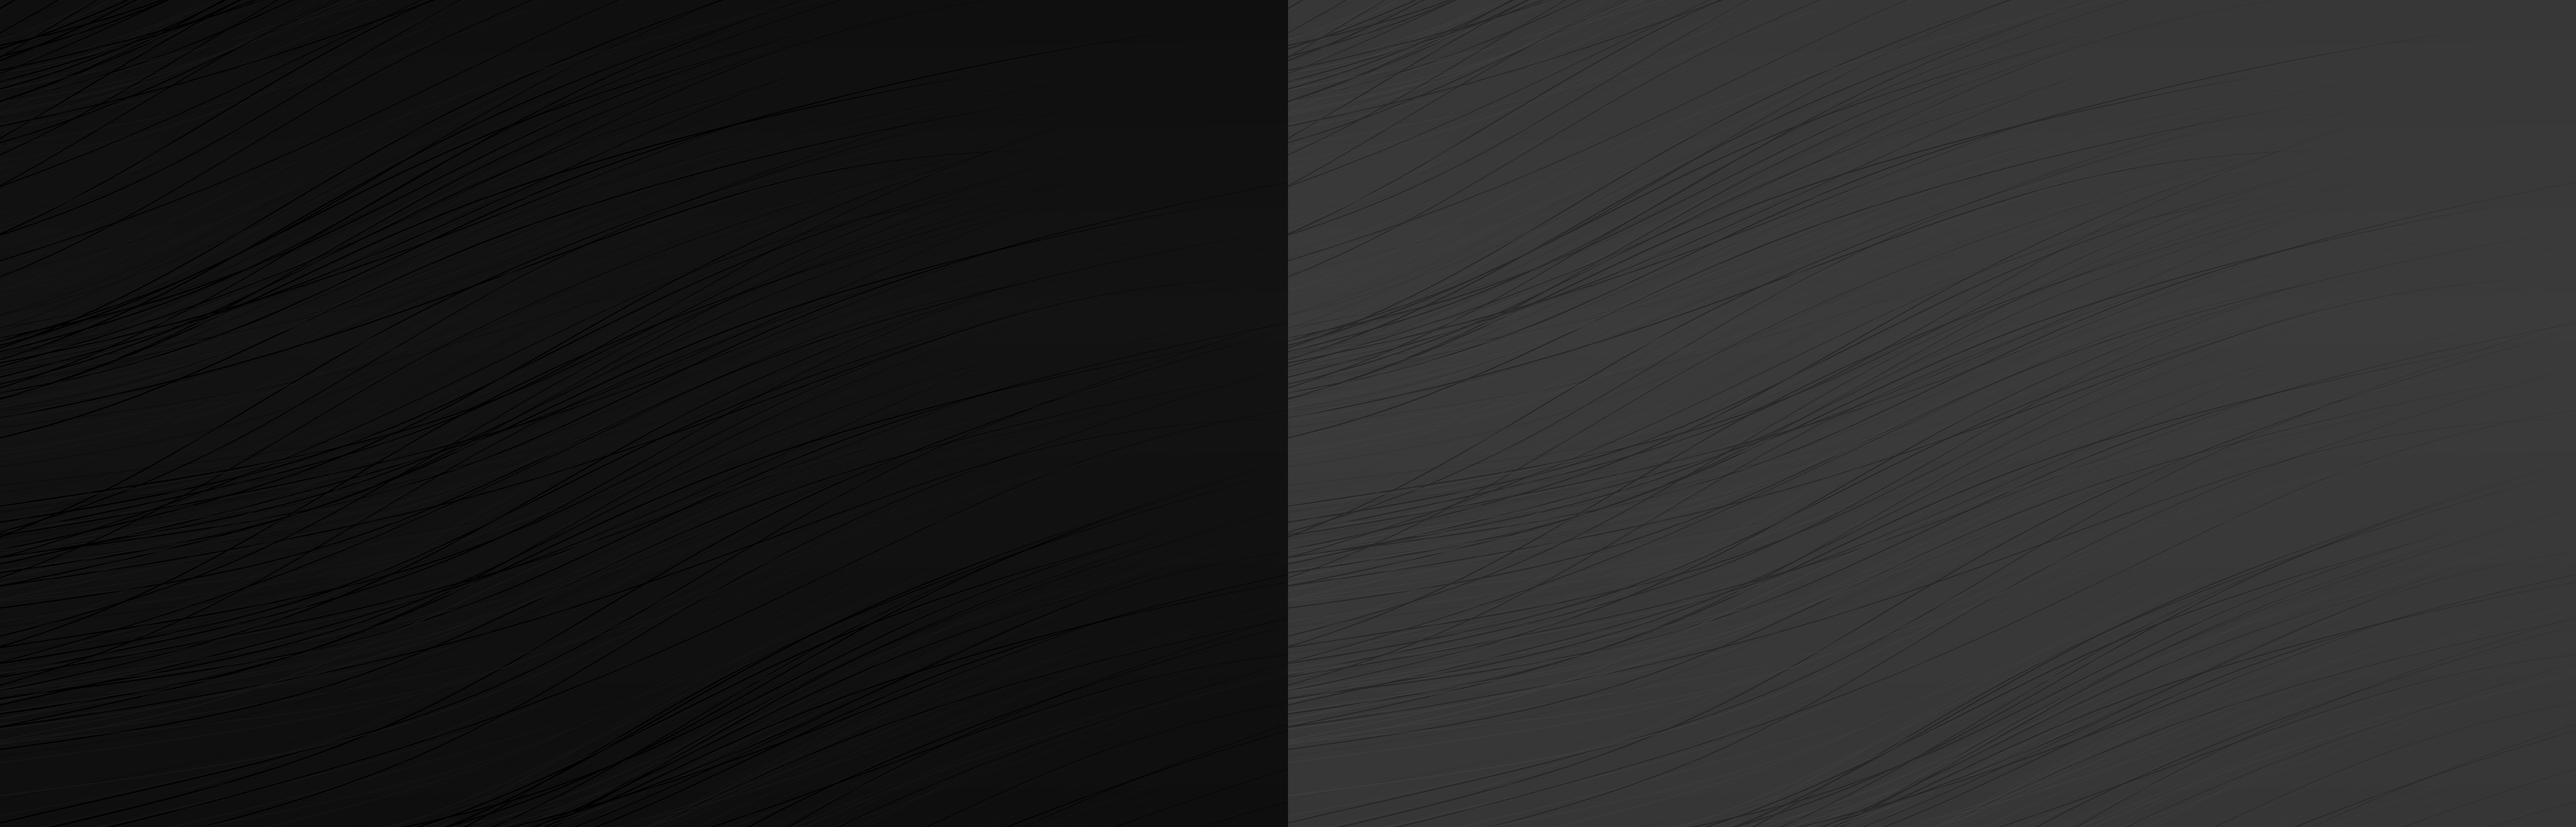

In [15]:
import cv2 as cv
import numpy as np
from google.colab.patches import cv2_imshow
print('Mengubah tingkat kecerahan citra')
print('--------------------------------')
try:
  brightness = int(input('Masukkan nilai kecerahan: '))
except ValueError:
  print('Error, not a number')

original = cv.imread('/content/drive/MyDrive/PCVK/Gambar/black_img.png')
brightness_image = np.zeros(original.shape, original.dtype)
brightness_image = np.clip(original.astype(np.int16) + brightness, 0, 255).astype(np.uint8)
final_frame = cv.hconcat((original,brightness_image))
cv2_imshow(final_frame)


---
##**TUGAS PRAKTIKUM**
---
1. Implementasikan inverse citra pada Google Colaboratory menggunakan formula pada
bagian Ulasan Teori. Terapkan pada KTM1b.jpg dan KTM1a.jpg, tampilkan
berdampingan dengan citra aslinya. Jelaskan mengapa citra negatif dari KTM1a
(ruangan gelap) tampak pucat dan berkabut, sedangkan negatif dari KTM1b tetap
kontras.

    Penjelasan:

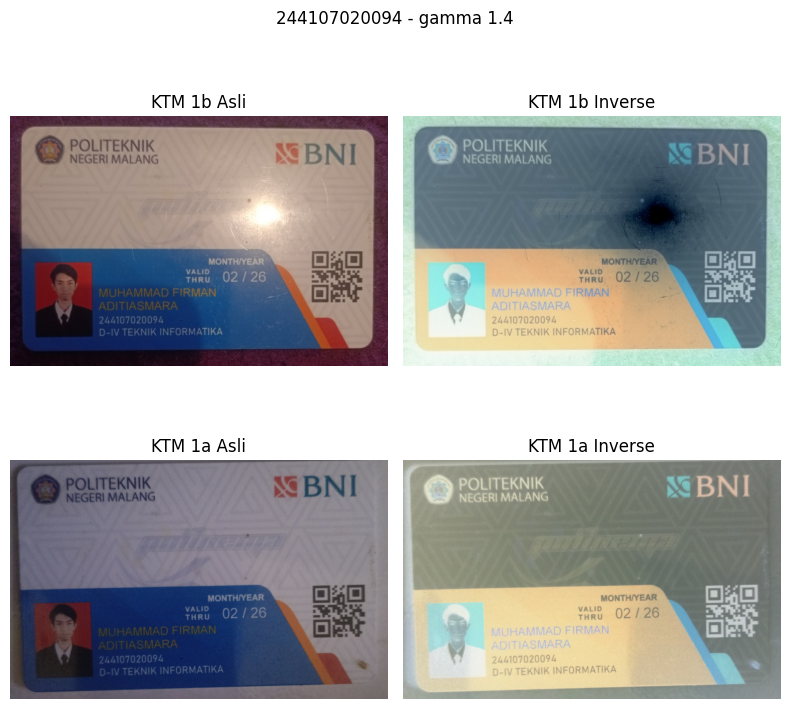

In [30]:
import cv2 as cv
import numpy as np
from google.colab.patches import cv2_imshow

image1 = cv.imread('/content/drive/MyDrive/PCVK/Gambar/KTM1b.jpg')
image2 = cv.imread('/content/drive/MyDrive/PCVK/Gambar/KTM1a.jpg')

# Konversi BGR ke RGB
image1_rgb = cv.cvtColor(image1, cv.COLOR_BGR2RGB)
image2_rgb = cv.cvtColor(image2, cv.COLOR_BGR2RGB)

# Inverse kedua gambar
inverse1 = 255 - image1_rgb
inverse2 = 255 - image2_rgb

# Tampilkan dengan subplot 2x2
fig = plt.figure(figsize=(8, 8))
fig.suptitle(NIM + ' - gamma ' + str(PARAM['gamma']))
plt.subplot(2, 2, 1)
plt.imshow(image1_rgb)
plt.title('KTM 1b Asli')
plt.axis('off')

plt.subplot(2, 2, 2)
plt.imshow(inverse1)
plt.title('KTM 1b Inverse')
plt.axis('off')

plt.subplot(2, 2, 3)
plt.imshow(image2_rgb)
plt.title('KTM 1a Asli')
plt.axis('off')

plt.subplot(2, 2, 4)
plt.imshow(inverse2)
plt.title('KTM 1a Inverse')
plt.axis('off')

plt.tight_layout()
plt.show()



2. Implementasikan transformasi kontras dengan nilai a yang dihitung dari NIM Anda
(PARAM['a']) pada KTM1a.jpg. Bentuk keluaran yang diharapkan seperti contoh
berikut:

Mengubah tingkat kontras dan kecerahan citra
-------------------------------------------
Masukkan nilai kontras: 1.4
Masukkan nilai kecerahan: 30


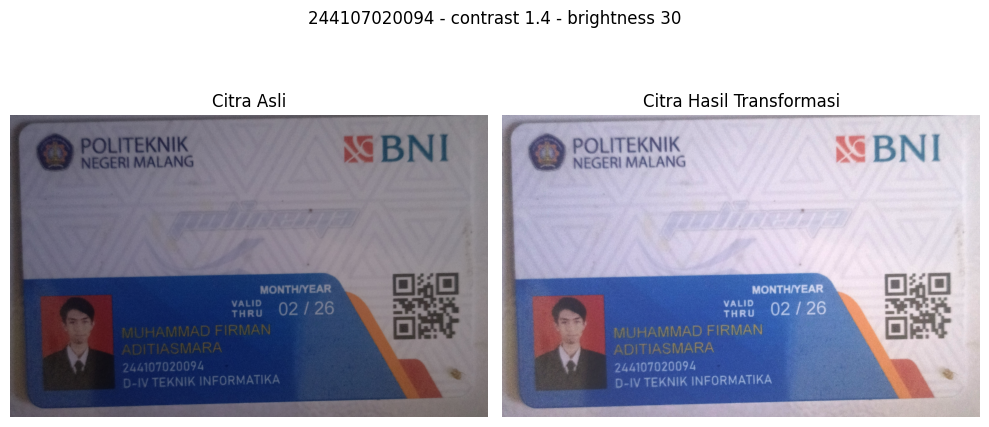

In [34]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

print('Mengubah tingkat kontras dan kecerahan citra')
print('-------------------------------------------')

contrast = float(input('Masukkan nilai kontras: '))
brightness = int(input('Masukkan nilai kecerahan: '))

original = cv.imread(
    '/content/drive/MyDrive/PCVK/Gambar/KTM1a.jpg'
)

if original is None:
    raise FileNotFoundError('File gambar tidak ditemukan')

# Konversi BGR ke RGB
original_rgb = cv.cvtColor(original, cv.COLOR_BGR2RGB)

# Rumus: g(x,y) = a * f(x,y) + b
contrast_image = (
    contrast * original_rgb.astype(np.float64)
    + brightness
)

# Membatasi nilai pixel ke rentang 0-255
contrast_image = np.clip(
    contrast_image, 0, 255
).astype(np.uint8)

# Menampilkan hasil
plt.figure(figsize=(10, 5))

plt.suptitle(
    '244107020094 - contrast '
    + str(contrast)
    + ' - brightness '
    + str(brightness)
)

plt.subplot(1, 2, 1)
plt.imshow(original_rgb)
plt.title('Citra Asli')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(contrast_image)
plt.title('Citra Hasil Transformasi')
plt.axis('off')

plt.tight_layout()
plt.show()

3. Implementasikan transformasi logarithmic brightness dengan konstanta c hasil hitung
dari NIM (PARAM['c']) pada KTM1a.jpg. Bandingkan hasilnya dengan linier brightness
memakai nilai b hasil hitung dari NIM (PARAM['b']) pada citra yang sama. Tentukan
metode mana yang membuat NIM pada kartu Anda lebih terbaca, dan tunjukkan
bagian mana yang menjadi putih penuh (clipping) pada masing-masing metode.
Bentuk keluaran yang diharapkan seperti contoh berikut:

Transformasi brightness citra
----------------------------
Masukkan nilai konstanta c: 44
Masukkan nilai kecerahan b: 53


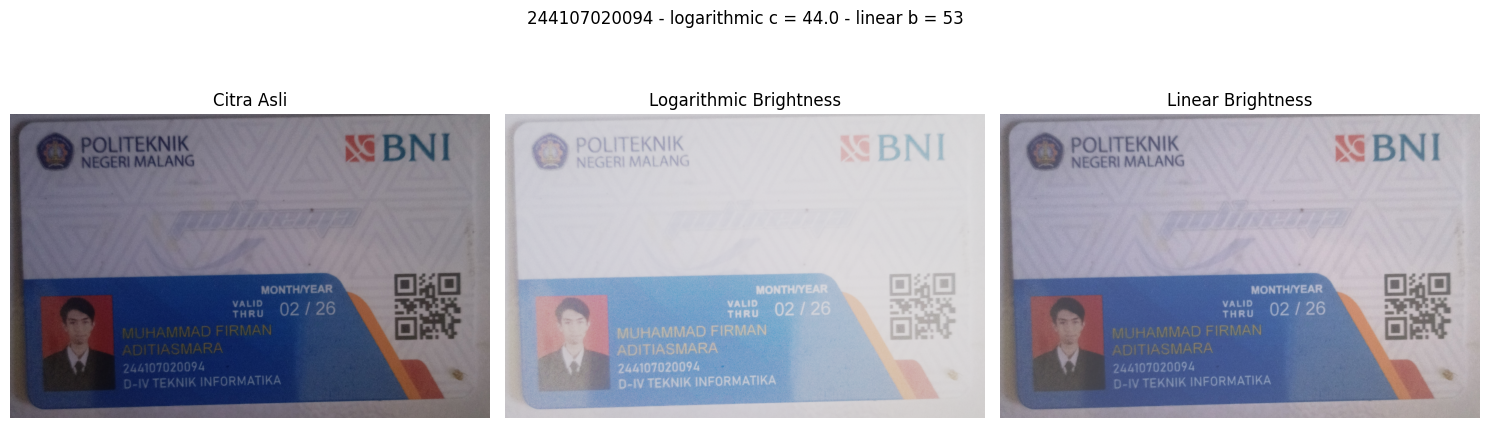

In [38]:
print('Transformasi brightness citra')
print('----------------------------')

try:
    c = float(input('Masukkan nilai konstanta c: '))
    b = int(input('Masukkan nilai kecerahan b: '))
except ValueError:
    print('Error: input harus berupa angka')
    raise SystemExit

# Membaca citra
original = cv.imread('/content/drive/MyDrive/PCVK/Gambar/KTM1a.jpg')

if original is None:
    raise FileNotFoundError('File KTM1a.jpg tidak ditemukan')

# Konversi BGR ke RGB
original_rgb = cv.cvtColor(original, cv.COLOR_BGR2RGB)

# Konversi ke float agar perhitungan tidak overflow
image_float = original_rgb.astype(np.float64)

# 1. Logarithmic brightness
# s = c * log(1 + r)
logarithmic_image = c * np.log1p(image_float)

# 2. Linear brightness
# g(x, y) = f(x, y) + b
linear_image = image_float + b

# Clipping ke rentang nilai pixel 0-255
logarithmic_image = np.clip(
    logarithmic_image, 0, 255
).astype(np.uint8)

linear_image = np.clip(
    linear_image, 0, 255
).astype(np.uint8)


plt.figure(figsize=(15, 5))

plt.suptitle(
    NIM
    + ' - logarithmic c = '
    + str(c)
    + ' - linear b = '
    + str(b)
)

plt.subplot(1, 3, 1)
plt.imshow(original_rgb)
plt.title('Citra Asli')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(logarithmic_image)
plt.title('Logarithmic Brightness')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(linear_image)
plt.title('Linear Brightness')
plt.axis('off')

plt.tight_layout()
plt.show()

4. Implementasikan transformasi grayscale metode averaging, lightness, dan luminance
pada KTM1c.jpg, yaitu citra yang diambil dengan flash. Hitung rata-rata dan
simpangan baku intensitas hasil ketiga metode, sajikan dalam satu tabel, lalu tentukan
metode mana yang memberi pemisahan paling jelas antara teks dan latar kartu.
Bentuk keluaran yang diharapkan seperti contoh berikut:

In [ ]:
original = cv.imread(
    '/content/drive/MyDrive/PCVK/Gambar/KTM1c.jpg'
)

if original is None:
    raise FileNotFoundError('File KTM1c.jpg tidak ditemukan')

# OpenCV membaca citra dalam format BGR
# Ubah ke RGB agar sesuai dengan rumus R, G, dan B
image = cv.cvtColor(original, cv.COLOR_BGR2RGB)

# Pisahkan channel R, G, dan B
R = image[:, :, 0].astype(np.float64)
G = image[:, :, 1].astype(np.float64)
B = image[:, :, 2].astype(np.float64)

# 1. Averaging
# Grayscale = (R + G + B) / 3
averaging = (R + G + B) / 3

# 2. Lightness
# Grayscale = (max(R,G,B) + min(R,G,B)) / 2
lightness = (np.maximum.reduce([R, G, B]) +
             np.minimum.reduce([R, G, B])) / 2

# 3. Luminance
# Grayscale = 0.21R + 0.72G + 0.07B
luminance = 0.21 * R + 0.72 * G + 0.07 * B

# Ubah hasil menjadi uint8
averaging = np.clip(averaging, 0, 255).astype(np.uint8)
lightness = np.clip(lightness, 0, 255).astype(np.uint8)
luminance = np.clip(luminance, 0, 255).astype(np.uint8)

# Menampilkan hasil
plt.figure(figsize=(10, 8))

plt.suptitle(NIM + ' - Grayscale')

plt.subplot(2, 2, 1)
plt.imshow(image)
plt.title('Citra Asli')
plt.axis('off')

plt.subplot(2, 2, 2)
plt.imshow(averaging, cmap='gray')
plt.title('Grayscale Averaging')
plt.axis('off')

plt.subplot(2, 2, 3)
plt.imshow(lightness, cmap='gray')
plt.title('Grayscale Lightness')
plt.axis('off')

plt.subplot(2, 2, 4)
plt.imshow(luminance, cmap='gray')
plt.title('Grayscale Luminance')
plt.axis('off')

plt.tight_layout()
plt.show()